                                                                                                by Maria 

# <center> Perceptron

In [1]:
import numpy as np
import pandas as pd
import math
import os
import time
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.express as px
import seaborn as sns; sns.set()

from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.metrics import recall_score, precision_score, accuracy_score, balanced_accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix, accuracy_score, precision_score, recall_score, precision_recall_curve, f1_score, roc_auc_score, auc, roc_curve

from sklearn import svm
from sklearn.svm import SVC, SVR 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from skimage import exposure

from sklearn.manifold import TSNE
from sklearn.utils import shuffle

import torch
import torch.nn as nn
import torch.optim as optim


from scipy import stats

from PIL import Image

from skimage.io import imread, imshow
from skimage import color
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
%matplotlib inline

import glob
import re
import random

import multiprocessing
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris

# 0. Исходные данные

    Задание №1

   На этой неделе у вас будет небольшая задача. Вам необходимо будет реализовать простейшую нейронную сеть на numpy - перцептрон.
    
1. Для данной задачи вам необходимо использовать один из первых и самых простых датасетов – Iris.
2. В датасете всего лишь 150 элементов, 4 фичи и 3 класса.
3. В целом, задачу классификации для данного датасета можно и логистической регрессией решить и SVC с линейным ядром. Пожалуйста сделайте такую классификацию - мы будет использовать её для референса. Наша нейронная сеть должна работать не хуже, чем данные классификаторы.
4. Для начала решим упрощённую задачу - ограничимся двумя классами и двумя фичами в этом датасете (соответствующие классы и фичи выберите сами).
5. Создайте перцептрон для решения данной задачи. Его архитектура должна быть представлена следующими элементами:
    1. Входные узлы (2 шт)
    2. Внутренний слой (который в данном случае будет представлять собой один сумматор)
    3. Функция активации (на выбор - функция Хэвисайда и сигмоида)
6. Реализуйте методы для:
    1. Предсказания классов объектов.
    2. Метод градиентного спуска для апдейта весов
    3. Оценки нейронной сети (на основе метрики Accuracy)
7. Ваша нейронная сеть должна работать не хуже, чем SVM с линейным ядром на том же датасете (выберите наилучшие C и Gamma параметры для классификатора)
8. Ваша программа должна быть реализована с помощью парадигмы объектно-ориентированного программирования

In [2]:
def visualize_images_from_folder(folder_path):
    image_files = [f for f in os.listdir(folder_path)]
    plt.figure(figsize=(len(image_files) * 5, 5))
    
    for i, file_name in enumerate(image_files):
        file_path = os.path.join(folder_path, file_name)
        try:
            image = imread(file_path)
            plt.subplot(1, len(image_files), i + 1)
            plt.imshow(image)
            plt.axis('off') 
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {e}")

    plt.tight_layout()
    plt.show()

# 1. Iris EDA (Exploratory Data Analysis)

![img](./data/img/2nd/iris-machinelearning.png)

In [3]:
df = px.data.iris()  
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [4]:
df.shape

(150, 6)

In [5]:
def check_spaces_in_column_names(df):
    columns_with_space = [col for col in df.columns if col.endswith(' ')]
    if columns_with_space:
        print("Столбцы с пробелом в конце названия:", columns_with_space)
    else:
        print("Пробелы в конце названий столбцов отсутствуют.")

In [6]:
check_spaces_in_column_names(df)

Пробелы в конце названий столбцов отсутствуют.


In [7]:
info_data = {
    'Признак': [],
    'Описание на русском': [],
    'Тип признака' : []
}

iris_about = {
    'sepal_length' : 'длина чашелистика см',
    'sepal_width' : 'ширина чашелистика см',
    'petal_length' : 'длина лепестка см',
    'petal_width' : 'ширина лепестка см',
    'species' : 'виды',
    'species_id' : 'идентификатор вида'
}

types = {
    'sepal_length' : 'Integer',
    'sepal_width' : 'Integer',
    'petal_length' : 'Integer',
    'petal_width' : 'Integer',
    'species' : 'Categorical',
    'species_id' : 'Integer'
}

for column in df.columns:
    info_data['Признак'].append(column)
    info_data['Описание на русском'].append(iris_about.get(column, ''))
    info_data['Тип признака'].append(types.get(column, ''))

info_df = pd.DataFrame(info_data)

### Основные выводы

In [8]:
pd.set_option('display.max_colwidth', None)
info_df

,Признак,Описание на русском,Тип признака
0,sepal_length,длина чашелистика см,Integer
1,sepal_width,ширина чашелистика см,Integer
2,petal_length,длина лепестка см,Integer
3,petal_width,ширина лепестка см,Integer
4,species,виды,Categorical
5,species_id,идентификатор вида,Integer


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
 5   species_id    150 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [10]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,2.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,1.000000
25%,5.100000,2.800000,1.600000,0.300000,1.000000
50%,5.800000,3.000000,4.350000,1.300000,2.000000
75%,6.400000,3.300000,5.100000,1.800000,3.000000
max,7.900000,4.400000,6.900000,2.500000,3.000000


## 1.1. Проверка наличия пропусков в данных

In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
species_id      0
dtype: int64

Пропусков нет

## 1.2. Проверка наличия дубликатов в данных

In [12]:
duplicates = df.duplicated()
print("Дубликаты в DataFrame:")
print(duplicates)

Дубликаты в DataFrame:
0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool


Полных дубликатов нет

## 1.3. Визуальный анализ признаков

### Виды ирисов

<Axes: xlabel='species', ylabel='count'>

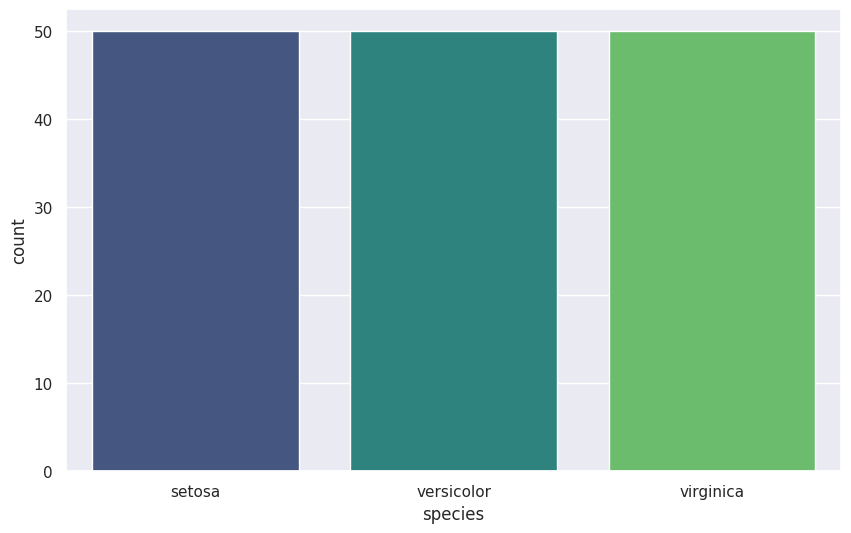

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='species', palette='viridis')

In [14]:
df.value_counts("species")

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Виды ирисов идеально сбалансированны

In [15]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
                 size='petal_width', hover_data=['petal_width'], facet_col="species")
fig.show()

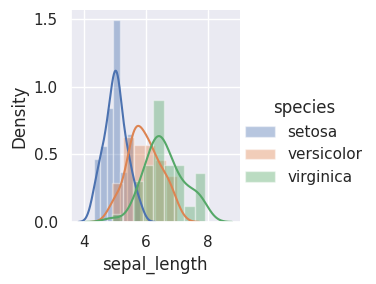

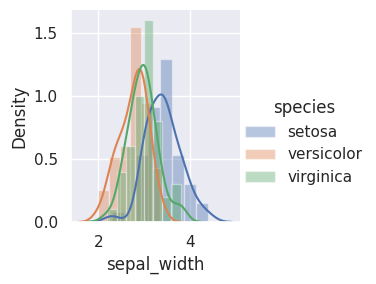

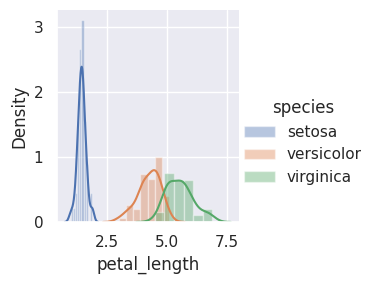

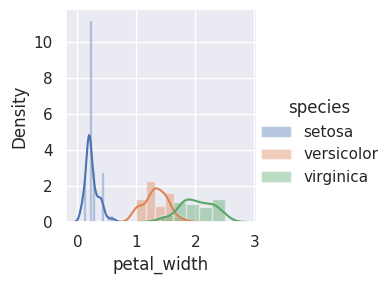

In [16]:
plot = sns.FacetGrid(df, hue="species")
plot.map(sns.distplot, "sepal_length").add_legend()

plot = sns.FacetGrid(df, hue="species")
plot.map(sns.distplot, "sepal_width").add_legend()

plot = sns.FacetGrid(df, hue="species")
plot.map(sns.distplot, "petal_length").add_legend()

plot = sns.FacetGrid(df, hue="species")
plot.map(sns.distplot, "petal_width").add_legend()

plt.show()

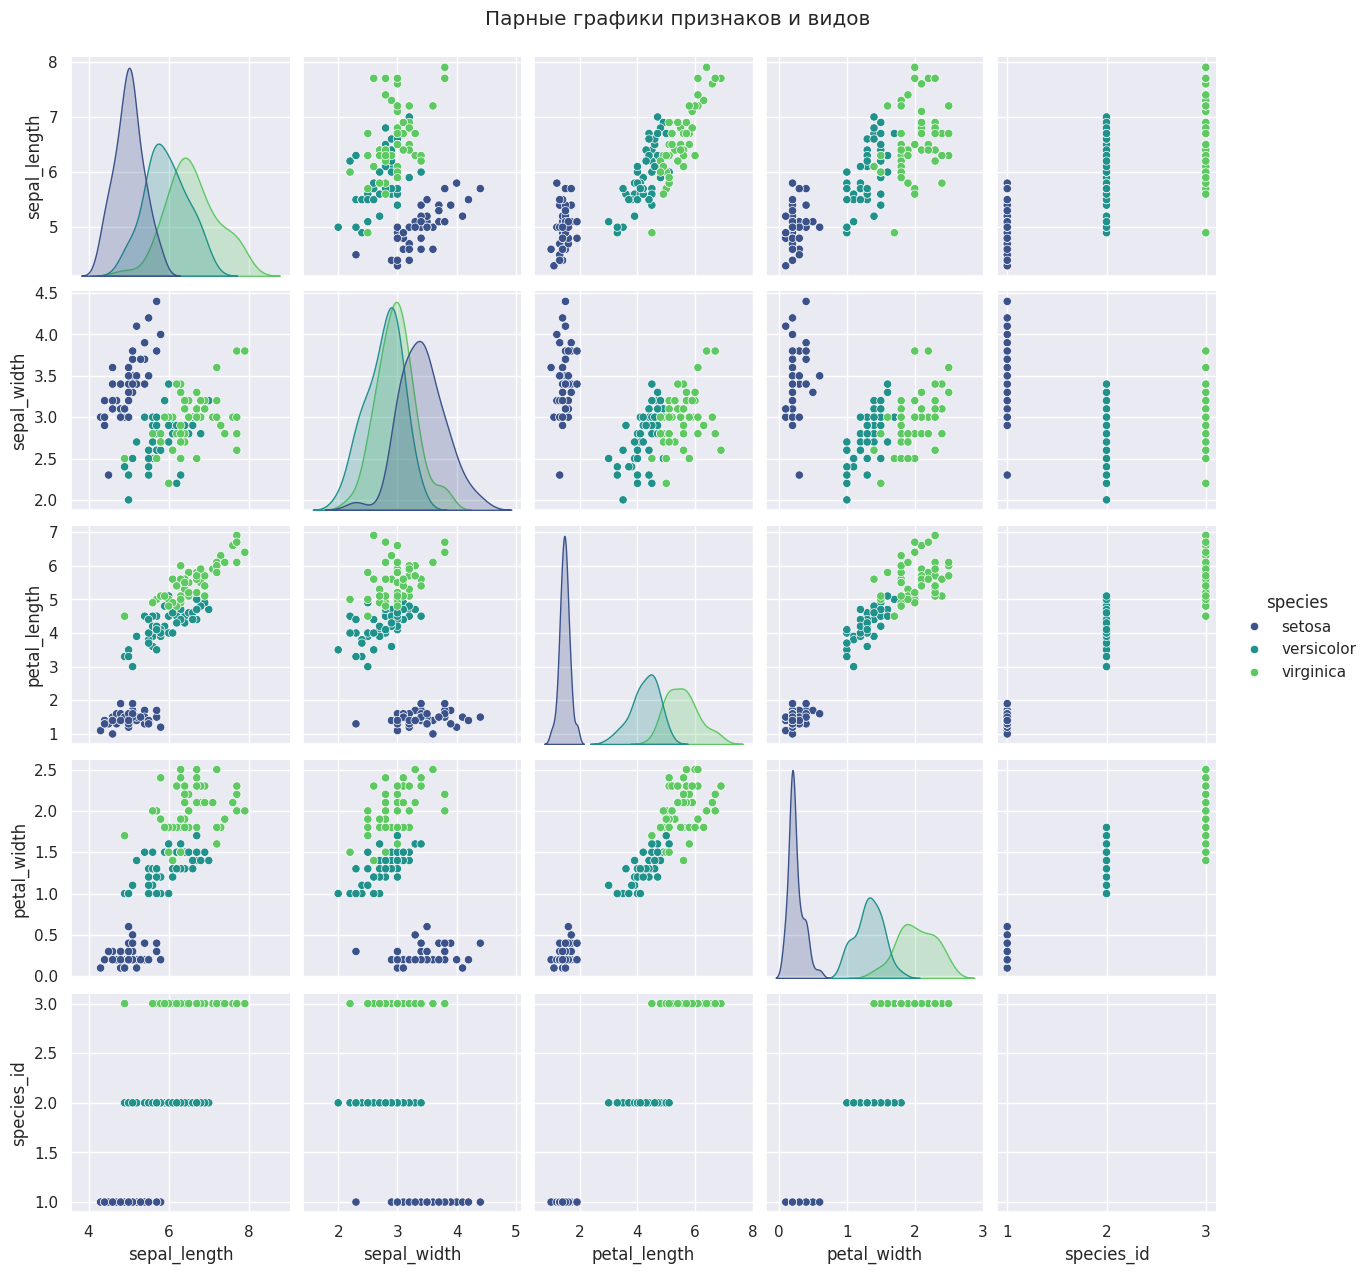

In [17]:
sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Парные графики признаков и видов', y=1.02)
plt.show()

## 1.4. Посмотрим на скоррелированность данных

In [18]:
data = df.drop('species', axis=1, inplace = False)

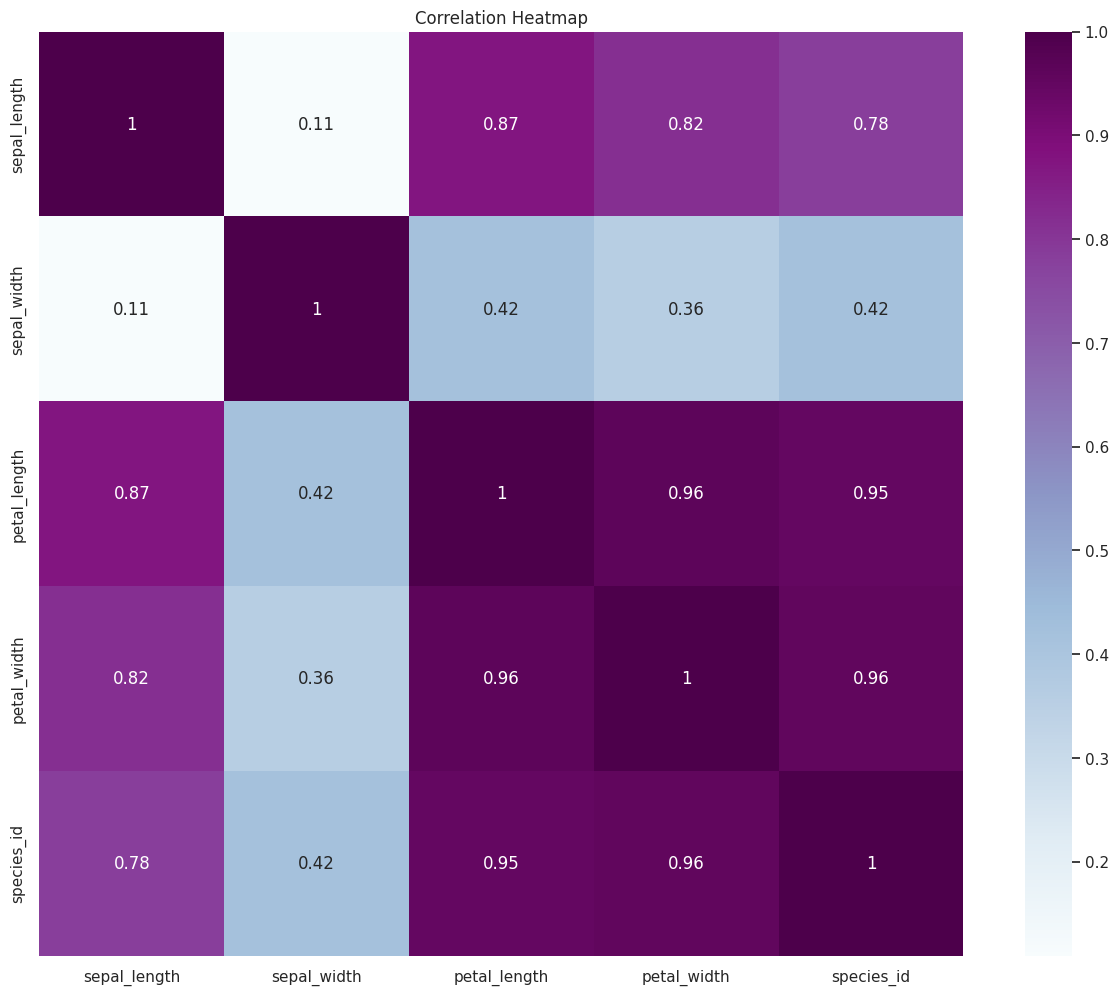

In [19]:
corr = abs(data.corr())
plt.figure(figsize=(16, 12))
sns.heatmap(corr, square=True, annot=True, cmap='BuPu')
plt.title('Correlation Heatmap')
plt.show()

### Основные выводы:
 - Ширина и длина лепестка сильно коррелируют (96%)
 - Длина лепестка и длина чашелистика сильно коррелируют (82%) 
 - Ширина лепестка и длина чашелистика сильно коррелируют (82%) 

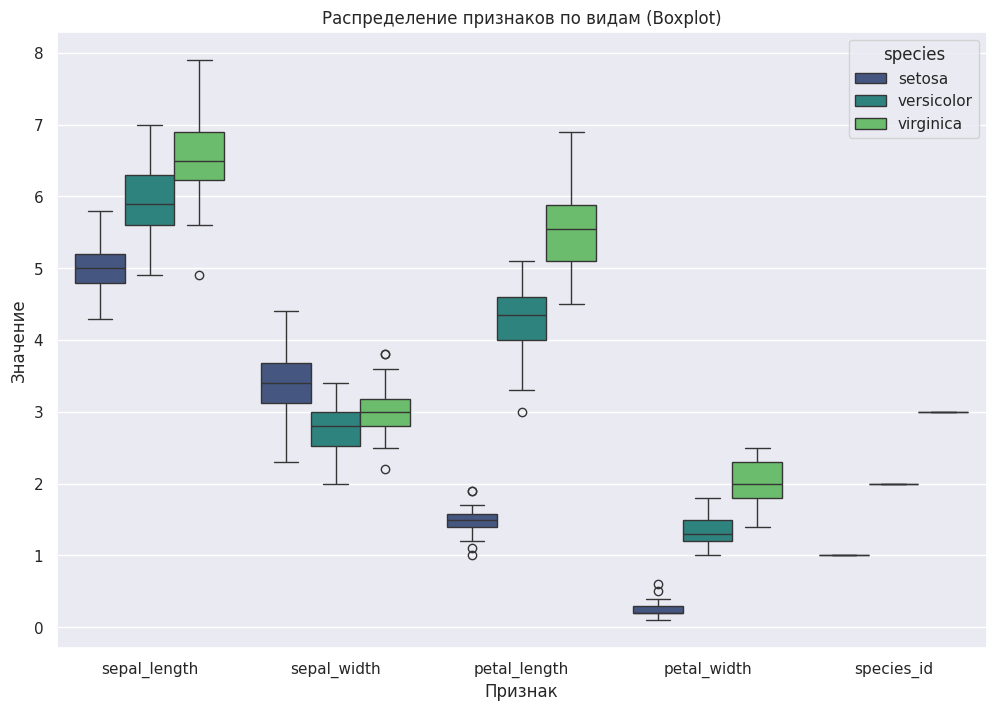

In [20]:
plt.figure(figsize=(12, 8))
iris_df_melted = pd.melt(df, id_vars="species", var_name="Признак", value_name="Значение")
sns.boxplot(x="Признак", y="Значение", hue="species", data=iris_df_melted, palette="viridis")
plt.title('Распределение признаков по видам (Boxplot)')
plt.show()

# 2. Logistic Regression Classification

In [21]:
data

,sepal_length,sepal_width,petal_length,petal_width,species_id
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,3
146,6.3,2.5,5.0,1.9,3
147,6.5,3.0,5.2,2.0,3
148,6.2,3.4,5.4,2.3,3


In [22]:
X = data.drop(['species_id'], axis=1, inplace = False)
y = data['species_id']

In [23]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [24]:
y

0      1
1      1
2      1
3      1
4      1
      ..
145    3
146    3
147    3
148    3
149    3
Name: species_id, Length: 150, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_pred_log_reg = log_reg.predict(X_test)

In [28]:
def metrics(y_test, y_pred):
    cf_matrix = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
    ac_score = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec_one = precision_score(y_test, y_pred, average=None)  
    rec_one = recall_score(y_test, y_pred, average=None)      
    f1_one = f1_score(y_test, y_pred, average=None)
    
    return cf_matrix, ac_score, prec, rec, f1, prec_one, rec_one, f1_one

In [31]:
def confusion_matrix_visualisation(cm):
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, square=True, annot=True, cmap='BuPu')
    plt.title('Confusion Matrix')
    plt.ylabel('Действительный класс')
    plt.xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

In [30]:
labels = [1, 2, 3]
BM = metrics(y_test, y_pred_log_reg);
print(f' Accuracy_score = {BM[1]}\n Precision = {BM[2]}, Recall = {BM[3]}\n F1_score = {BM[4]}\n')

 Accuracy_score = 1.0
 Precision = 1.0, Recall = 1.0
 F1_score = 1.0



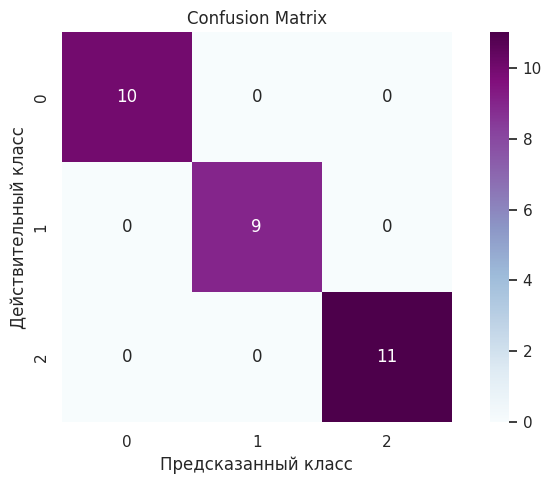

In [31]:
confusion_matrix_visualisation(BM[0])

In [32]:
classes = [1, 2, 3]  
for idx, cls in enumerate(classes):
    print(f"Metrics for class {cls}:")
    print(f"  Precision: {BM[5][idx]:.4f}")
    print(f"  Recall: {BM[6][idx]:.4f}")
    print(f"  F1 Score: {BM[7][idx]:.4f}")

Metrics for class 1:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Metrics for class 2:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Metrics for class 3:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000


# 3. SVM Classification

In [33]:
svc_linear = SVC(kernel='linear')
svc_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [34]:
y_pred_svc = svc_linear.predict(X_test)

In [35]:
BM1 = metrics(y_test, y_pred_svc);
print(f' Accuracy_score = {BM1[1]}\n Precision = {BM1[2]}, Recall = {BM1[3]}\n F1_score = {BM1[4]}\n')

 Accuracy_score = 1.0
 Precision = 1.0, Recall = 1.0
 F1_score = 1.0



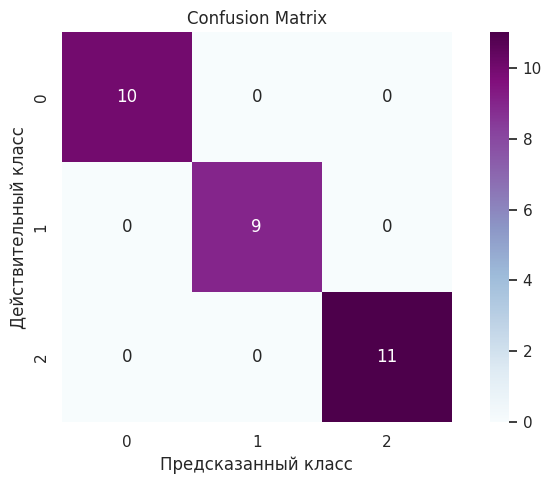

In [36]:
confusion_matrix_visualisation(BM1[0])

In [37]:
classes = [0, 1, 2]  
for idx, cls in enumerate(classes):
    print(f"Metrics for class {cls}:")
    print(f"  Precision: {BM1[5][idx]:.4f}")
    print(f"  Recall: {BM1[6][idx]:.4f}")
    print(f"  F1 Score: {BM1[7][idx]:.4f}")

Metrics for class 0:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Metrics for class 1:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Metrics for class 2:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000


# 4. Perceptron (elementary)

In [38]:
fp1 = './data/img/1st'

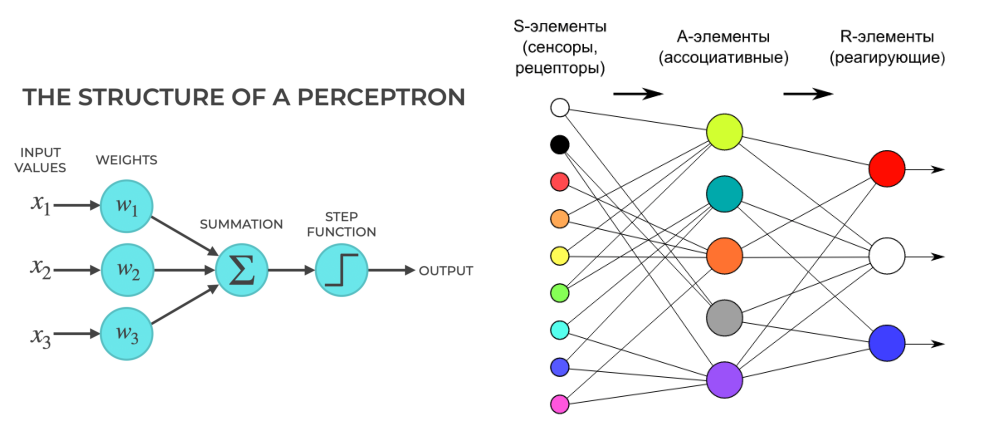

In [39]:
visualize_images_from_folder(fp1)

### Перцептрон (англ. Perceptron) — простейший вид нейронных сетей. В основе лежит математическая модель восприятия информации мозгом, состоящая из сенсоров, ассоциативных и реагирующих элементов.

Принцип работы перцептрона следующий:

1. Первыми в работу включаются S-элементы. Они могут находиться либо в состоянии покоя (сигнал равен 0), либо в состоянии возбуждения (сигнал равен 1);
2. Далее сигналы от S-элементов передаются A-элементам по так называемым S-A связям. Эти связи могут иметь веса, равные только -1, 0 или 1;
3. Затем сигналы от сенсорных элементов, прошедших по S-A связям, попадают в A-элементы, которые еще называют ассоциативными элементами;
     - Одному A-элементу может соответствовать несколько S-элементов;
     - Если сигналы, поступившие на A-элемент, в совокупности превышают некоторый его порог ​θ​, то этот A-элемент возбуждается и выдает сигнал, равный 1;
     - В противном случае (сигнал от S-элементов не превысил порога A-элемента), генерируется нулевой сигнал;
4. Далее сигналы, которые произвели возбужденные A-элементы, направляются к сумматору (R-элемент), действие которого нам уже известно. Однако, чтобы добраться до R-элемента, они проходят по A-R связям, у которых тоже есть веса (которые уже могут принимать любые значения, в отличие от S-A связей);
5. R-элемент складывает друг с другом взвешенные сигналы от A-элементов, а затем
     - если превышен определенный порог, генерирует выходной сигнал, равный 1;
     - eсли порог не превышен, то выход перцептрона равен -1.
     
   Для элементов перцептрона используют следующие названия:

 - S-элементы называют сенсорами;
 - A-элементы называют ассоциативными;
 - R-элементы называют реагирующими.

<b> Перцептрон с одним скрытым слоем (элементарный перцептрон, англ. elementary perceptron)</b> — перцептрон, у которого имеется только по одному слою S, A и R элементов.

<b> Однослойный персептрон (англ. Single-layer perceptron)</b> — перцептрон, каждый S-элемент которого однозначно соответствует одному А-элементу, S-A связи всегда имеют вес 1, а порог любого А-элемента равен 1. Часть однослойного персептрона соответствует модели искусственного нейрона.

Его ключевая особенность состоит в том, что каждый S-элемент однозначно соответствует одному A-элементу, все S-A связи имеют вес, равный +1, а порог A элементов равен 1. Часть однослойного перцептрона, не содержащая входы, соответствует искусственному нейрону, как показано на картинке. Таким образом, однослойный перцептрон — это искусственный нейрон, который на вход принимает только 0 и 1.

Однослойный персептрон также может быть и элементарным персептроном, у которого только по одному слою S,A,R-элементов.

Ограничимся двумя классами и двумя фичами в этом датасете 

Опираясь на EDA выше, можно сделать следующие предположения
1. Если мы хотим более строго и достоверно оценить работу нашего перцептрона в задаче классификации, разумно будет выбрать в качетсве пары классов versicolor и virginica, поскольку классификатору сложнее будет справиться с разделением более схожих классов. (Либо можно сделать также shuffle класса setosa и пополам раскидать по двум классам)
    А если мы напротив хотим создать удобные условия для упрощённой задачи классификации - подойдут  setosa и versicolor: Эти классы довольно различные и обычно хорошо разделимы в пространстве признаков.
    
2. Два признака стоит выбрать самых значимых, это просто сделать при помощи PCA. Но также из матрицы корреляции п1.4 видно, что нам подойдут sepal_length и petal_length

In [40]:
df_binary = df[df['species'].isin(['setosa', 'versicolor'])]

In [41]:
data_binary = df_binary.drop(['species'], axis=1, inplace=False)

In [42]:
df_binary['species'].unique()

array(['setosa', 'versicolor'], dtype=object)

In [43]:
X_reduced = data_binary.drop(['species_id'], axis=1, inplace=False)
y_reduced = data_binary['species_id'].apply(lambda x: 0 if x < 2 else 1)

In [44]:
y_reduced

0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: species_id, Length: 100, dtype: int64

### Нормировка данных

In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [47]:
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['species'] = df_binary['species'].values

<Axes: xlabel='Principal Component 1', ylabel='Principal Component 2'>

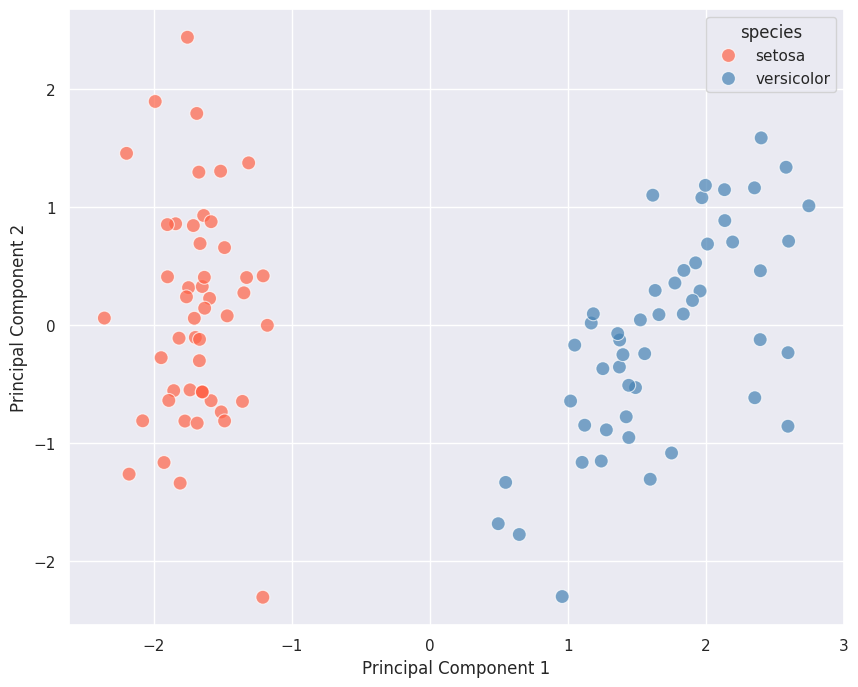

In [48]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
  x='Principal Component 1', 
  y='Principal Component 2', 
  hue='species',
  palette=['#FF6347', '#4682B4'],
  data=pca_df,
  s=100, 
  alpha=0.7
)

In [49]:
loadings = pca.components_

In [50]:
features = X_reduced.columns
pca_loadings_df = pd.DataFrame(loadings, columns=features, index=['PC1', 'PC2'])
print("Веса признаков в главных компонентах:")
print(pca_loadings_df)


Веса признаков в главных компонентах:
     sepal_length  sepal_width  petal_length  petal_width
PC1      0.479319    -0.366723      0.567776     0.559819
PC2      0.544540     0.836615      0.029732     0.051654


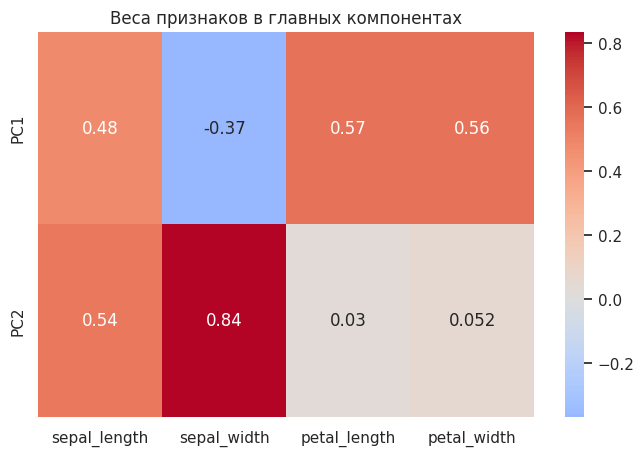

In [51]:
plt.figure(figsize=(8, 5))
sns.heatmap(pca_loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title('Веса признаков в главных компонентах')
plt.show()

In [52]:
y_reduced = np.array(y_reduced)

In [53]:
X_train_p1, X_test_p1, y_train_p1, y_test_p1 = train_test_split(X_pca, y_reduced, test_size=0.2, random_state=42)

In [54]:
print(f' X_train.shape = {X_train_p1.shape}\n X_test.shape = {X_test_p1.shape}\n y_train.shape = {y_train_p1.shape}\n \
y_test.shape = {y_test_p1.shape} ')

 X_train.shape = (80, 2)
 X_test.shape = (20, 2)
 y_train.shape = (80,)
 y_test.shape = (20,) 


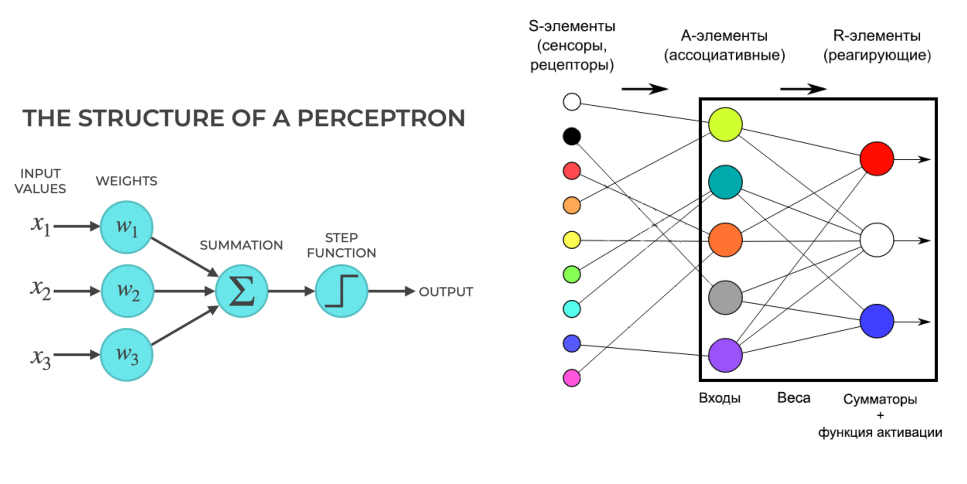

In [55]:
fp3 = './data/img/3rd'
visualize_images_from_folder(fp3)

## Обучение перцептрона
    Задача обучения перцептрона — подобрать такие w0,w1,w2,…,wn, чтобы sign(σ(w0+w1⋅x1+w2⋅x2+…+wn⋅xn)) как можно чаще совпадал с y(x) — значением в обучающей выборке (здесь σ — функция активации). Для удобства, чтобы не тащить за собой свободный член w0 
                            sign(σ(wT⋅x)), x=(1,x1,x2,…,xn)

Чтобы обучать эту функцию, выберем функцию ошибки, которую потом можно оптимизировать градиентным спуском. 
Будем использовать так называемый критерий перцептрона: 
<b> $E_{P}(w) = -∑_{x∈M}y(x) ·σ(w^T ·x)$ </b>, где M
 — множество примеров, которые перцептрон с весами w классифицирует неправильно.

<b>$E_{P}(w)$ </b> можно оптимизировать градиентным спуском.
На очередном шаге получаем: <b>$w(τ+1)=w(τ)−η▽_wE_{P}(w)$ </b>


Алгоритм такой — мы последовательно проходим примеры x1,x2,… из обучающего множества, и для каждого <b>$x_n$ </b>:

 - если он классифицирован правильно, не меняем ничего;
 - а если неправильно, прибавляем <b>$η▽_wE_{P}(w)$ </b>

In [56]:
class ElementaryPerceptron:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate  
        self.epochs = epochs  
        self.weights = None  
        self.bias = None 

    def activation_function(self, x):
        """Используем сигмоиду в качестве функции активации."""
        return 1 / (1 + np.exp(-x))
    
    def linear_combination(self, X):
        """Вычисление линейной комбинации признаков и весов с учетом смещения."""
        return np.dot(X, self.weights) + self.bias
        
    def fit(self, X, y):
        """Обучение с использованием стохастического градиентного спуска."""
        self.weights = np.random.rand(X.shape[1])
        self.bias = np.random.rand()

        for _ in range(self.epochs):
            for i in range(len(y)):
                self.update_weights(X[i], y[i])

    def update_weights(self, x_i, y_true):
        """Обновление весов и смещения по одному образцу."""
        z = np.dot(x_i, self.weights) + self.bias  
        y_pred = self.activation_function(z)                   

        error = y_true - y_pred
        self.weights += self.learning_rate * error * x_i
        self.bias += self.learning_rate * error
        
    def predict(self, X):
        """Предсказание классов."""
        z = self.linear_combination(X)
        y_pred = self.activation_function(z)
        return np.where(y_pred >= 0.5, 1, 0)
    
    def accuracy(self, y_true, y_pred):
        """Оценка точности классификации."""
        return np.mean(y_true == y_pred)
    
    def precision(self, y_true, y_pred):
        """Вычисление precision (versicolor — целевой класс)."""
        true_positive = np.sum((y_pred == 1) & (y_true == 1))
        false_positive = np.sum((y_pred == 1) & (y_true == 0))
        return true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0

    def recall(self, y_true, y_pred):
        """Вычисление recall (versicolor — целевой класс)."""
        true_positive = np.sum((y_pred == 1) & (y_true == 1))
        false_negative = np.sum((y_pred == 0) & (y_true == 1))
        return true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0

    def f1_score(self, y_true, y_pred):
        """Вычисление F1-скор (versicolor — целевой класс)."""
        prec = self.precision(y_true, y_pred)
        rec = self.recall(y_true, y_pred)
        return 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    def confusion_matrix(self, y_true, y_pred):
        """Построение confusion matrix."""
        true_positive = np.sum((y_pred == 1) & (y_true == 1))
        true_negative = np.sum((y_pred == 0) & (y_true == 0))
        false_positive = np.sum((y_pred == 1) & (y_true == 0))
        false_negative = np.sum((y_pred == 0) & (y_true == 1))
        return np.array([[true_positive, false_negative], [false_positive, true_negative]])

In [57]:
perceptron1 = ElementaryPerceptron(learning_rate=0.01, epochs=1000)

start_time = time.time()
perceptron1.fit(X_train_p1, y_train_p1)
fit_time_p1 = time.time() - start_time
print(f"Время обучения перцептрона: {fit_time_p1:.4f} секунд")

Время обучения перцептрона: 0.3955 секунд


In [58]:
y_pred = perceptron1.predict(X_test_p1)
accuracy = perceptron1.accuracy(y_test_p1, y_pred)
precision = perceptron1.precision(y_test_p1, y_pred)
recall = perceptron1.recall(y_test_p1, y_pred)
f1 = perceptron1.f1_score(y_test_p1, y_pred)
conf_matrix = perceptron1.confusion_matrix(y_test_p1, y_pred)

In [59]:
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print("Confusion matrix:\n", conf_matrix)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-score: 1.00
Confusion matrix:
 [[ 8  0]
 [ 0 12]]


Попробуем SVC с линейным ядром и оптимальным C по результату гридсерча

In [60]:
len_c = 10
arr_beg = np.linspace(0.1, 1, len_c)
arr_end = np.linspace(1, 10, len_c)
arr = np.concatenate((arr_beg[:-1], arr_end), axis=0)

In [61]:
svc = SVC()
param_grid={
    'C': arr,
    'kernel': ['linear']
    }

gs=GridSearchCV(svc,param_grid=param_grid, cv=3,
                n_jobs=-1, scoring='accuracy')

start_time = time.time()
gs.fit(X_train_p1, y_train_p1);
fit_time_svc1 = time.time() - start_time
print(f"Время обучения SVC: {fit_time_svc1:.4f} секунд")

Время обучения SVC: 1.9123 секунд


In [62]:
gs.best_params_

{'C': 0.1, 'kernel': 'linear'}

In [63]:
gs.best_score_

1.0

In [64]:
y_pred_gs = gs.best_estimator_.predict(X_test_p1)

In [65]:
def bin_metrics(y_test, y_pred):
    cf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ac_score = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec_one = precision_score(y_test, y_pred, average=None)  
    rec_one = recall_score(y_test, y_pred, average=None)      
    f1_one = f1_score(y_test, y_pred, average=None)
    
    return cf_matrix, ac_score, prec, rec, f1, prec_one, rec_one, f1_one

In [66]:
BMgs = bin_metrics(y_test_p1, y_pred_gs);
print(f' Accuracy_score = {BMgs[1]}\n Precision = {BMgs[5]}, Recall = {BMgs[6]}\n F1_score = {BMgs[7]}\n')

 Accuracy_score = 1.0
 Precision = [1. 1.], Recall = [1. 1.]
 F1_score = [1. 1.]



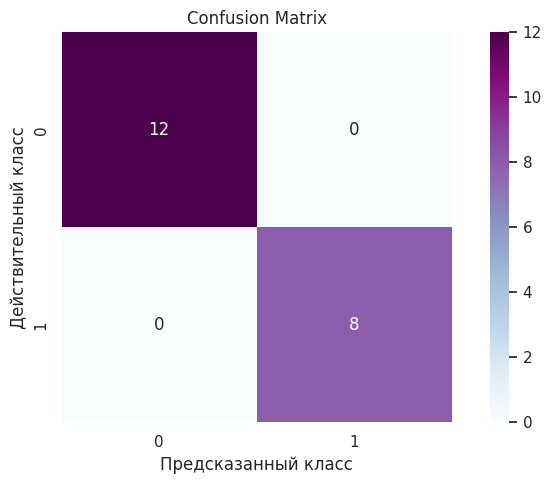

In [67]:
confusion_matrix_visualisation(BMgs[0])

In [68]:
times_partial_svc_p1 = fit_time_svc1/fit_time_p1
times_partial_svc_p1

4.834847514921801

Наш юный перцептрон работает не хуже! А обучается в 4.8 раза быстрее SVC

  Задание №2

1. Когда разберетесь с простейшим перцептроном, давайте расширим его функционал и сделаем простейший многослойный перцептрон. Теперь вам необходимо работать со всеми классами и фичами в датасете. Таким образом ваша нейронная сеть должна состоять из:
    1. 4 входных узла
    2. Первый Внутренний слой должен состоять из 1 или 2 сумматоров (можно задавать опционально)
    3. Второй внутренний слой за ним должен быть ещё один внутренний слой, состоящий из 1 сумматора
    4. Функция активации – сигмоида.

# 5. Multi-Layer Perceptron

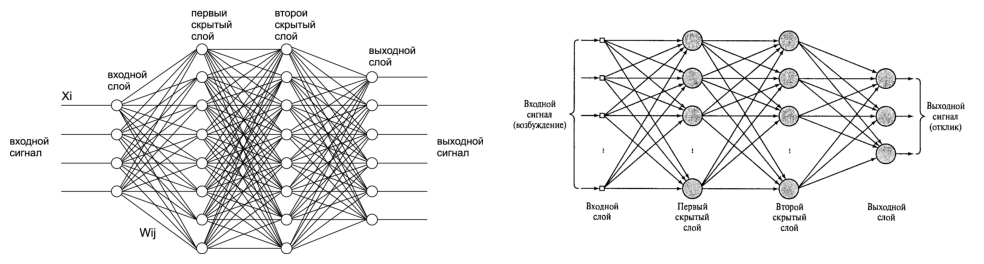

In [69]:
fp4 = './data/img/4th'
visualize_images_from_folder(fp4)

Многослойный перцептрон по Розенблатту (англ. Rosenblatt multilayer perceptron) — перцептрон, который содержит более 1 слоя А-элементов.


Многослойный перцептрон по Румельхарту (англ. Rumelhart multilater perceptron) — частный случай многослойного персептрона по Розенблатту, с двумя особенностями:

 - S-A связи могут иметь произвольные веса и обучаться наравне с A-R связями;
 - Обучение производится по специальному алгоритму, который называется обучением по методу обратного распространения ошибки.


Softmax и Cross-entropy обычно используются вместе в задаче многоклассовой классификации, где цель состоит в том, чтобы определить, к какому классу принадлежит входной сигнал.

Когда мы используем softmax и кросс-энтропию вместе, градиенты выходного слоя (ошибки для обновления весов) становятся проще и точнее

<b> Функция Softmax </b>
(https://www.parasdahal.com/softmax-crossentropy)

   Функция Softmax берет N-мерный вектор вещественных чисел и преобразует его в вектор вещественных чисел в диапазоне (0,1), которые складываются до 1.

<span style="font-size:20px;"> <b> $p_i = \frac{e^{a_{i}}}{∑_{k=1}^{N} e^{a}_{k}}  $ </b> </span>

Как следует из названия, функция softmax - это «мягкая» версия функции max. Вместо того чтобы выбирать одно максимальное значение, она разбивает все (1), при этом максимальный элемент получает наибольшую часть распределения, но и другие меньшие элементы также получают часть распределения.
Это свойство функции softmax - выдавать распределение вероятностей - делает ее пригодной для вероятностной интерпретации в задачах классификации.

```
def softmax(X):
    exps = np.exp(X)
    return exps / np.sum(exps)
```

<span style="font-size:20px;"> <b> $p_i = \frac{e^{a_i + \log(C)}}{\sum_{k=1}^N e^{a_k + \log(C)}} $ </b> </span>

Чтобы избежать переполнения, используем устойчивую версию Softmax:

<span style="font-size:20px;"> <b> $p_i = \frac{e^{a_i - C}}{\sum_{k=1}^N e^{a_k - C}}$ </b> </span>, где  <b> $C=max(a)$ </b>


```
def stable_softmax(X):
    exps = np.exp(X - np.max(X))
    return exps / np.sum(exps)
```    
<b> Производная Softmax </b>

Для использования Softmax в нейронных сетях необходимо вычислить его производную для обратного распространения ошибки:

<span style="font-size:20px;"> <b> $\frac{\partial p_i}{\partial a_j} = p_i (\delta_{ij} - p_j)$ </b> </span>
где  <b> $\delta_{ij}$ </b> — это дельта Кронекера:

$$
\delta_{ij} = 
\begin{cases} 
1, & \text{если } i = j \\
0, & \text{если } i \neq j 
\end{cases}
$$

Таким образом, производная Softmax имеет следующие формы:

$$
\frac{\partial a_j}{\partial p_i} =
\begin{cases} 
p_i (1 - p_i), & \text{если } i = j \\
-p_j p_i, & \text{если } i \neq j 
\end{cases}
$$





<b> Кросс-энтропия </b>

Кросс-энтропия измеряет расстояние между распределением вероятностей, которое предсказывает модель, и истинным распределением:

$$
H(y, p) = -\sum_i y_i log(p_i)
$$

Эта функция потерь часто используется для классификации с активацией softmax на выходном слое, так как интерпретирует результаты как вероятности.

```
def cross_entropy(X, y):
    m = y.shape[0]
    p = softmax(X)
    log_likelihood = -np.log(p[range(m), y])
    loss = np.sum(log_likelihood) / m
    return loss
```

<b> Производная Cross Entropy с Softmax </b>

При совместном использовании Cross Entropy и Softmax, градиент потерь по выходу имеет простое выражение:

<span style="font-size:20px;"> <b>$\frac{\partial L}{\partial o_i} = p_i - y_i$</b> </span>, где $y_{i}$ — метка класса в формате one-hot
```
def delta_cross_entropy(X, y):
    m = y.shape[0]
    grad = softmax(X)
    grad[range(m), y] -= 1
    grad = grad / m
    return grad
```
Для меток в виде целых чисел y производная функции потерь Cross Entropy по предсказанным значениям $p_{i}$ для примеров $i$ записывается так же, как и для one-hot представления, но без необходимости one-hot кодирования:
<span style="font-size:20px;"> <b>$\frac{\partial L}{\partial o_i} = p_{i} - 1$ </b> </span>, если  $i$ = класс,  иначе <span style="font-size:20px;"> <b> $\frac{\partial L}{\partial o_i} = p_i$</b> </span>

```
def delta_cross_entropy(X, y):
    m = y.shape[0]
    grad = softmax(X)
    grad[range(m), y] -= 1  # вычитаем 1 только для вероятностей, соответствующих истинному классу
    grad = grad / m
    return grad
```

Имеем: 4 входа, два скрытых слоя (первый — с 1 или 2 сумматорами, второй — с 1 сумматором) и 3 выходных узла по узлу для класса.

In [ ]:
class MultiLayerPerceptron:
    def __init__(self, input_size=4, hidden_layer1_size=8, hidden_layer2_size=6, output_size=3, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        
        self.weights_input_hidden1 = np.random.rand(input_size, hidden_layer1_size)
        self.weights_hidden1_hidden2 = np.random.rand(hidden_layer1_size, hidden_layer2_size)
        self.weights_hidden2_output = np.random.rand(hidden_layer2_size, output_size)
        
        self.bias_hidden1 = np.zeros((1, hidden_layer1_size))
        self.bias_hidden2 = np.zeros((1, hidden_layer2_size))
        self.bias_output = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))  
        return e_x / e_x.sum(axis=1, keepdims=True)

    def cross_entropy_loss(self, output, y):
        m = y.shape[0]
        log_likelihood = -np.log(output[np.arange(m), y])
        loss = np.sum(log_likelihood) / m
        return loss

    def forward_pass(self, X):
        self.hidden1 = self.sigmoid(np.dot(X, self.weights_input_hidden1) + self.bias_hidden1)
        self.hidden2 = self.sigmoid(np.dot(self.hidden1, self.weights_hidden1_hidden2) + self.bias_hidden2)
        self.output = self.softmax(np.dot(self.hidden2, self.weights_hidden2_output) + self.bias_output)
        return self.output

    def backward_pass(self, X, y, output):
        m = y.shape[0]
        
        output_error = output
        output_error[np.arange(m), y] -= 1
        output_error /= m

        hidden2_error = output_error.dot(self.weights_hidden2_output.T)
        hidden2_delta = hidden2_error * self.sigmoid_derivative(self.hidden2)

        hidden1_error = hidden2_delta.dot(self.weights_hidden1_hidden2.T)
        hidden1_delta = hidden1_error * self.sigmoid_derivative(self.hidden1)

        self.weights_hidden2_output -= self.learning_rate * self.hidden2.T.dot(output_error)
        self.weights_hidden1_hidden2 -= self.learning_rate * self.hidden1.T.dot(hidden2_delta)
        self.weights_input_hidden1 -= self.learning_rate * X.T.dot(hidden1_delta)

        self.bias_output -= self.learning_rate * np.sum(output_error, axis=0, keepdims=True)
        self.bias_hidden2 -= self.learning_rate * np.sum(hidden2_delta, axis=0, keepdims=True)
        self.bias_hidden1 -= self.learning_rate * np.sum(hidden1_delta, axis=0, keepdims=True)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        train_losses = []
        val_losses = []

        for epoch in range(self.epochs):
            output = self.forward_pass(X_train)
            loss = self.cross_entropy_loss(output, y_train)
            train_losses.append(loss)
            self.backward_pass(X_train, y_train, output)

            val_output = self.forward_pass(X_val)
            val_loss = self.cross_entropy_loss(val_output, y_val)
            val_losses.append(val_loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Training Loss: {loss:.4f}  Validation Loss: {val_loss:.4f}")

        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.title('Loss over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
        
    def predict(self, X):
        output = self.forward_pass(X)
        return np.argmax(output, axis=1)

    def compute_metrics(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))

        precision = np.diag(cm) / np.sum(cm, axis=0)  
        recall = np.diag(cm) / np.sum(cm, axis=1)     
        f1_score = 2 * (precision * recall) / (precision + recall)  

        accuracy = np.trace(cm) / np.sum(cm)
        
        self.class_metrics = {label: {'precision': precision[i], 'recall': recall[i], 'f1_score': f1_score[i]}
                                  for i, label in enumerate(np.unique(y_true))}
        self.confusion_matrix = cm
        self.accuracy = accuracy

In [71]:
scaler1 = StandardScaler()
X_scaled1 = scaler1.fit_transform(X)
X_scaled1.shape

(150, 4)

In [72]:
y_mlp = np.array(y.apply(lambda x: x-1))
y_mlp.shape

(150,)

In [73]:
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X_scaled1, y_mlp, test_size=0.2, random_state=42)

In [74]:
print(f' X_train.shape = {X_train_mlp.shape}\n X_test.shape = {X_test_mlp.shape}\n y_train.shape = {y_train_mlp.shape}\n \
y_test.shape = {y_test_mlp.shape} ')

 X_train.shape = (120, 4)
 X_test.shape = (30, 4)
 y_train.shape = (120,)
 y_test.shape = (30,) 


In [ ]:
mlp = MultiLayerPerceptron(input_size=4, hidden_layer1_size=2, hidden_layer2_size=1, output_size=3, learning_rate=0.6, epochs=700)
start_time = time.time()
mlp.fit(X_train_mlp, y_train_mlp, X_test_mlp, y_test_mlp)
fit_time_p2 = time.time() - start_time
print(f"\nВремя обучения MLP: {fit_time_p2:.4f} секунд")

In [76]:
y_pred_mlp = mlp.predict(X_test_mlp)

In [77]:
mlp.compute_metrics(y_test_mlp, y_pred_mlp)

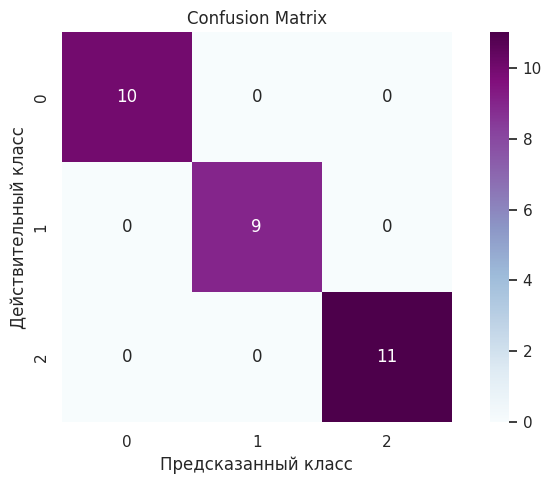

In [78]:
confusion_matrix_visualisation(mlp.confusion_matrix)

In [79]:
print(f'\nAccuracy: {mlp.accuracy} \n Class-specific metrics:')
for label, metrics_mlp in mlp.class_metrics.items():
    print(f"Class {label}\n  Precision: {metrics_mlp['precision']:.2f}\n  Recall: {metrics_mlp['recall']:.2f}\n \
 F1-Score: {metrics_mlp['f1_score']:.2f}")


Accuracy: 1.0 
 Class-specific metrics:
Class 0
  Precision: 1.00
  Recall: 1.00
  F1-Score: 1.00
Class 1
  Precision: 1.00
  Recall: 1.00
  F1-Score: 1.00
Class 2
  Precision: 1.00
  Recall: 1.00
  F1-Score: 1.00


Как видим, метрики идеальные. При этом время обучения - всего  0.1144 секунд!
Проверим насколько это быстрее и лучше многоклассовой классификации с помощью SVC с наилучшими параметрами.

In [80]:
svc2 = SVC()
param_grid={
    'C': arr,
    'gamma': arr,
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    }

gs2=GridSearchCV(svc,param_grid=param_grid, cv=3,
                n_jobs=-1, scoring='balanced_accuracy')
start_time = time.time()
gs2.fit(X_train_mlp, y_train_mlp);
fit_time_svc_multi = time.time() - start_time
print(f'Время обучения SVC (3 класса): {fit_time_svc_multi:.4f} секунд')

Время обучения SVC (3 класса): 3.3485 секунд


In [81]:
gs2.best_params_

{'C': 5.0, 'gamma': 0.1, 'kernel': 'sigmoid'}

In [82]:
gs2.best_score_

0.9761904761904762

In [83]:
y_pred_gs2 = gs2.best_estimator_.predict(X_test_mlp)

In [84]:
def metrics_012(y_test, y_pred):
    cf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    ac_score = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec_one = precision_score(y_test, y_pred, average=None)  
    rec_one = recall_score(y_test, y_pred, average=None)      
    f1_one = f1_score(y_test, y_pred, average=None)
    
    return cf_matrix, ac_score, prec, rec, f1, prec_one, rec_one, f1_one

In [85]:
BM_gs2 = metrics_012(y_test_mlp, y_pred_gs2);
print(f' Accuracy_score = {BM_gs2[1]}\n Precision = {BM_gs2[2]}, Recall = {BM_gs2[3]}\n F1_score = {BM_gs2[4]}\n')

 Accuracy_score = 0.9666666666666667
 Precision = 0.9694444444444444, Recall = 0.9666666666666667
 F1_score = 0.9664109121909632



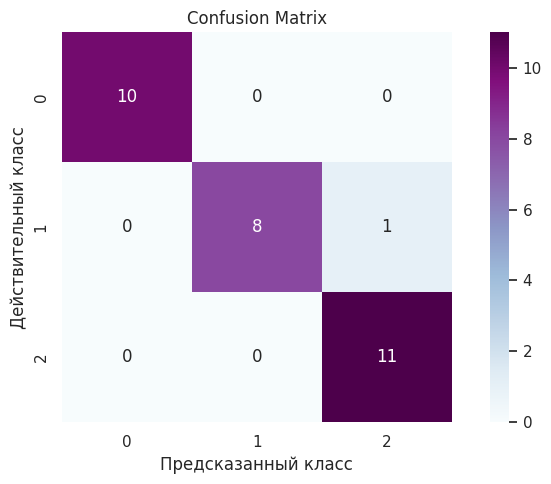

In [86]:
confusion_matrix_visualisation(BM_gs2[0])

In [87]:
classes = [0, 1, 2]  
for idx, cls in enumerate(classes):
    print(f"Metrics for class {cls}:")
    print(f"  Precision: {BM_gs2[5][idx]:.4f}")
    print(f"  Recall: {BM_gs2[6][idx]:.4f}")
    print(f"  F1 Score: {BM_gs2[7][idx]:.4f}")

Metrics for class 0:
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
Metrics for class 1:
  Precision: 1.0000
  Recall: 0.8889
  F1 Score: 0.9412
Metrics for class 2:
  Precision: 0.9167
  Recall: 1.0000
  F1 Score: 0.9565


In [88]:
times_partial_svc_p2 = fit_time_svc_multi/fit_time_p2
times_partial_svc_p2

6.672389440652964

Видим, что у SVC, хоть метрики и хорошие, но не идеальные, как у MLP. К тому же время обучения выше АЖ в 20+ раз

Задание №3
1.  Как только у вас получится классифицировать Iris датасет с помощью своего перцептрона, давайте перейдём к более сложной задаче. Теперь вам необходимо расширить функционал вашего перцептрона.
    1. Количестов входных узлов должно быть произвольным
    2. Количество сумматоров на первом и втором внутреннем слое должно быть произвольным
    3. Количество выходных узлов должно быть произвольным (и соответстоввать количеству классов)
    4. Функция активации - сигмоида
2. Попробуйте модифицировать свой перцептрон для классификации MNIST датасета. Сравните с работой SVC в его наилучшей конфигурации (С и гамма).

# 6. MNIST EDA (from one of the previous projects)

In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
X_mn, y_mn = mnist["data"], mnist["target"]

In [4]:
print(X_mn.shape, y_mn.shape)

(70000, 784) (70000,)


## 6.1 Проверка на пропуски

In [5]:
print("NaN in X:", X_mn.isnull().any().any())
print("NaN in y:", y_mn.isnull().any())

NaN in X: False
NaN in y: False


## 6.2 Обработка данных

### 6.2.1. Нормируем значения пикселей на максимум (значения пикселей находятся в диапазоне от 0 до 255)

In [6]:
X_mn /= 255

### 6.2.2. Преобразуем таргет в целочисленный 

In [7]:
y_mn = y_mn.astype(int)

In [8]:
y_mn

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: int64

<Axes: >

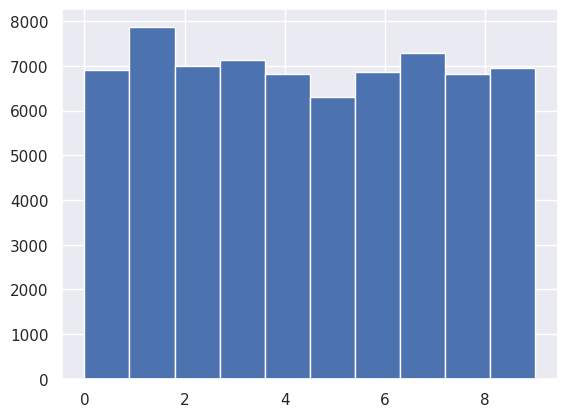

In [9]:
y_mn.hist()

Классы распределены равномерно

In [10]:
X_mn

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6.3. Анализ признакового пространства

### 6.3.1. Визуализация нескольких рандомно выбранных картинок

In [11]:
images = X_mn.to_numpy().reshape(-1, 28, 28)

In [12]:
indices = np.random.choice(len(images), 20, replace=False)
sample_images = images[indices]

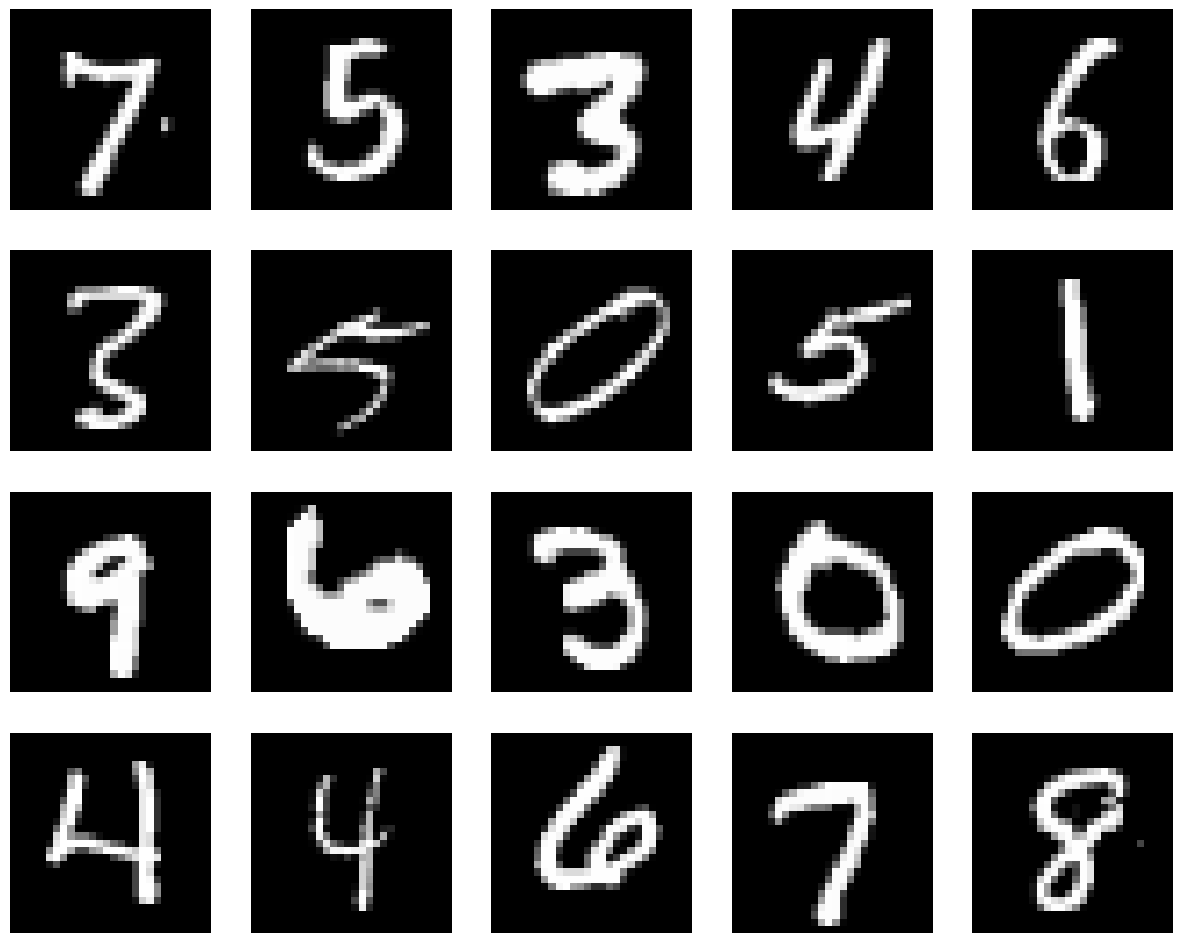

In [13]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i], cmap='gray')
    ax.axis('off')  
    
plt.show()

### 6.3.2. Визуализация с t-SNE

In [14]:
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X_mn) 

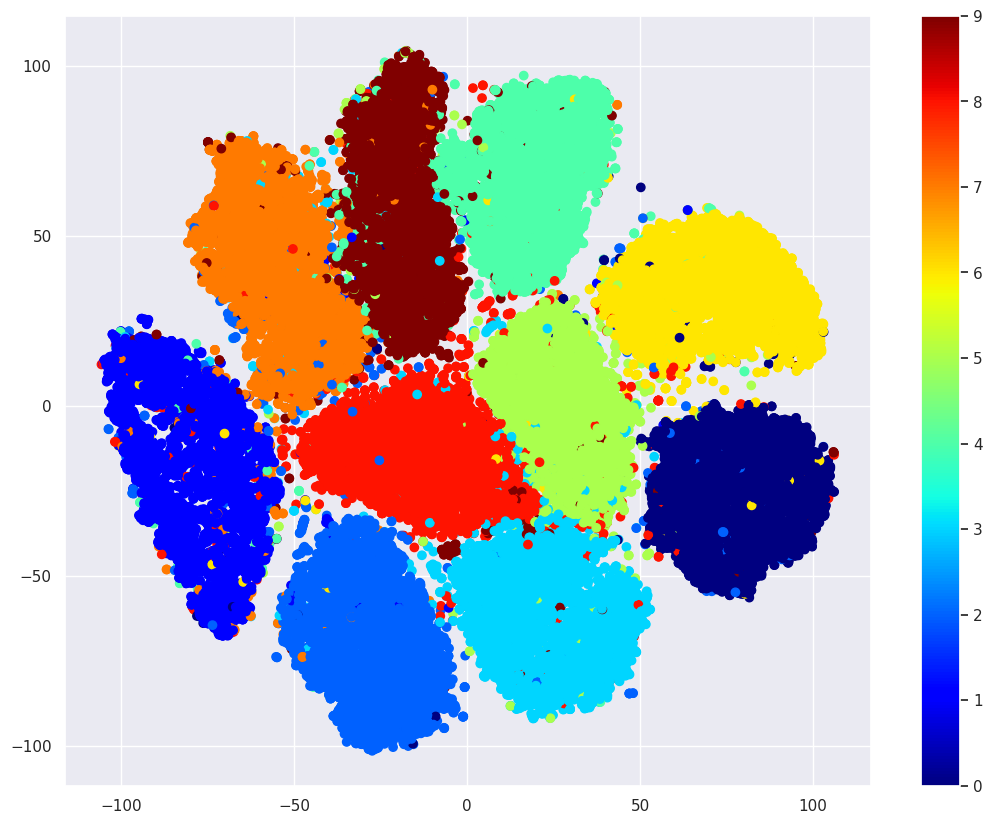

In [15]:
plt.figure(figsize=(13,10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_mn, cmap="jet")
plt.colorbar()
plt.show()

# 7. MNIST SVC

По опыту в классификации mnist датасета в одном из предыдущих проектов выяснили, что лучше всего с этой задачей справляется svc на хог-фичах без color-фич

In [16]:
def create_hog_features(images):
    hog_features = []
    for image in images:
        fd, hog_image = hog(image, orientations=8, pixels_per_cell=(3, 3),
                    cells_per_block=(1, 1), visualize=True, channel_axis=None)
        hog_features.append(fd)
    return np.array(hog_features)

## 7.2. Подбор лучших параметров SVC на reduced mnist (обрезанном к 21х21 и сжатом к 8х8)

In [17]:
train_dir='/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/Reduced Training data'
test_dir='/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/Reduced Testing data'
train_list=[]
test_list=[]

for i in range(10):
    train_list.append(glob.glob('{}/{}/*.jpg'.format(train_dir,i)))
    test_list.append(glob.glob('{}/{}/*.jpg'.format(test_dir,i)))

train_list = [item for sublist in train_list for item in sublist]
test_list = [item for sublist in test_list for item in sublist]

train_data = np.array([np.array(Image.open(fname)) \
                              for fname in train_list])
test_data = np.array([np.array(Image.open(fname)) \
                             for fname in test_list])

train_label=np.array([list(map(int, re.findall(r'\b\d\b', fname)))[0]  for fname in train_list])
test_label=np.array([list(map(int, re.findall(r'\b\d\b', fname)))[0]  for fname in test_list])

X_train_reduced, y_train_reduced = shuffle(train_data.reshape(-1, 28*28)/255, train_label)
X_test_reduced, y_test_reduced= shuffle(test_data.reshape(-1, 28*28)/255, test_label)

## 7.3. Обучение модели и её предсказание 

In [18]:
images.shape

(70000, 28, 28)

In [19]:
X_hog = create_hog_features(images)

In [20]:
X_hog.shape

(70000, 648)

In [21]:
y_mn = np.array(y_mn)
y_mn

array([5, 0, 4, ..., 4, 5, 6])

In [22]:
X_train_mn, X_test_mn, y_train_mn, y_test_mn = train_test_split(X_hog, y_mn, test_size=0.2, random_state=42)

In [23]:
print(f' X_train.shape = {X_train_mn.shape}\n X_test.shape = {X_test_mn.shape}\n y_train.shape = {y_train_mn.shape}\n \
y_test.shape = {y_test_mn.shape} ')

 X_train.shape = (56000, 648)
 X_test.shape = (14000, 648)
 y_train.shape = (56000,)
 y_test.shape = (14000,) 


In [24]:
svс_mn = SVC(gamma='scale')
start_time = time.time()
svс_mn.fit(X_train_mn, y_train_mn)
fit_time_svс_mn = time.time() - start_time

In [25]:
fit_time_svс_mn

152.4989583492279

In [26]:
params_mn = svс_mn.get_params()
params_mn

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [27]:
y_pred_mn = svс_mn.predict(X_test_mn)

In [28]:
def metrics_0123456789(y_test, y_pred):
    cf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    ac_score = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec_one = precision_score(y_test, y_pred, average=None)  
    rec_one = recall_score(y_test, y_pred, average=None)      
    f1_one = f1_score(y_test, y_pred, average=None)
    
    return cf_matrix, ac_score, prec, rec, f1, prec_one, rec_one, f1_one

In [29]:
mn_metr = metrics_0123456789(y_test_mn, y_pred_mn)

print(f"Accuracy Score with HOG features: {mn_metr[1]}")
print(f"Precision with HOG features: {mn_metr[2]}")
print(f"Recall with HOG features: {mn_metr[3]}")
print(f"F1 Score with HOG features: {mn_metr[4]}")

Accuracy Score with HOG features: 0.9867857142857143
Precision with HOG features: 0.9867915211598522
Recall with HOG features: 0.9867857142857143
F1 Score with HOG features: 0.9867808039163526


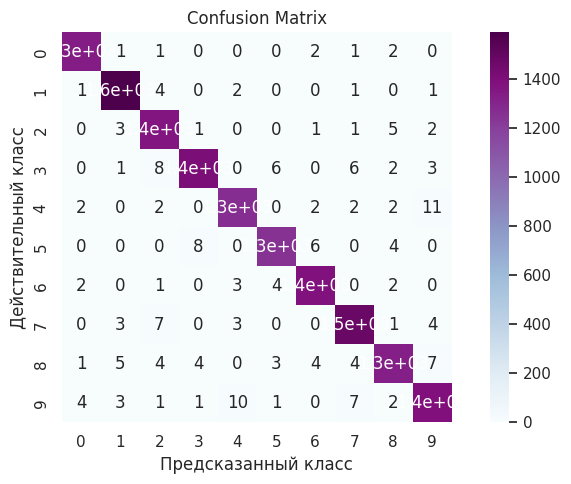

In [32]:
confusion_matrix_visualisation(mn_metr[0])

In [33]:
classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
for idx, cls in enumerate(classes):
    print(f"Metrics for class {cls}:")
    print(f"  Precision: {mn_metr[5][idx]:.4f}")
    print(f"  Recall: {mn_metr[6][idx]:.4f}")
    print(f"  F1 Score: {mn_metr[7][idx]:.4f}")

Metrics for class 0:
  Precision: 0.9926
  Recall: 0.9948
  F1 Score: 0.9937
Metrics for class 1:
  Precision: 0.9900
  Recall: 0.9944
  F1 Score: 0.9922
Metrics for class 2:
  Precision: 0.9799
  Recall: 0.9906
  F1 Score: 0.9852
Metrics for class 3:
  Precision: 0.9901
  Recall: 0.9819
  F1 Score: 0.9860
Metrics for class 4:
  Precision: 0.9861
  Recall: 0.9838
  F1 Score: 0.9849
Metrics for class 5:
  Precision: 0.9890
  Recall: 0.9859
  F1 Score: 0.9874
Metrics for class 6:
  Precision: 0.9893
  Recall: 0.9914
  F1 Score: 0.9903
Metrics for class 7:
  Precision: 0.9854
  Recall: 0.9880
  F1 Score: 0.9867
Metrics for class 8:
  Precision: 0.9851
  Recall: 0.9764
  F1 Score: 0.9808
Metrics for class 9:
  Precision: 0.9803
  Recall: 0.9796
  F1 Score: 0.9799


# 8. FlexibleMLP  :))

![img](./data/img/4th/04_156-1.jpg)

In [64]:
class FlexibleMLP:
    def __init__(self, input_size, hidden_layer1_size, hidden_layer2_size, output_size, learning_rate=0.005, epochs=100, batch_size=32, lambda_reg=1.0):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.lambda_reg = lambda_reg
        
        self.weights_input_hidden1 = np.random.randn(input_size, hidden_layer1_size) 
        self.weights_hidden1_hidden2 = np.random.randn(hidden_layer1_size, hidden_layer2_size) 
        self.weights_hidden2_output = np.random.randn(hidden_layer2_size, output_size)
    
        self.bias_hidden1 = np.zeros(hidden_layer1_size)
        self.bias_hidden2 = np.zeros(hidden_layer2_size)
        self.bias_output = np.zeros(output_size)
        
        self.train_losses = []
        self.val_losses = []
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        return x * (1 - x)
    
    def softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))  
        return e_x / e_x.sum(axis=1, keepdims=True)
    
    def forward_pass(self, X):
        self.hidden1 = self.sigmoid(np.dot(X, self.weights_input_hidden1) + self.bias_hidden1)
        self.hidden2 = self.sigmoid(np.dot(self.hidden1, self.weights_hidden1_hidden2) + self.bias_hidden2)
        
        output = self.softmax(np.dot(self.hidden2, self.weights_hidden2_output) + self.bias_output)
        return output
    
    def cross_entropy_loss(self, output, y):
        m = y.shape[0]
        log_likelihood = -np.log(output[np.arange(m), y])
        loss = np.sum(log_likelihood) / m
        
        l2_loss = (self.lambda_reg / (2 * m)) * (
            np.sum(np.square(self.weights_input_hidden1)) +
            np.sum(np.square(self.weights_hidden1_hidden2)) +
            np.sum(np.square(self.weights_hidden2_output))
        )
        
        return loss + l2_loss

    def softmax_cross_entropy_backward(self, output, y):
        output_error = output.copy()
        output_error[np.arange(len(y)), y] -= 1
        output_error /= len(y)  
        return output_error

    def backward_pass(self, X, y, output):
        output_error = self.softmax_cross_entropy_backward(output, y)
        
        hidden2_error = output_error.dot(self.weights_hidden2_output.T)
        hidden2_delta = hidden2_error * self.sigmoid_derivative(self.hidden2)

        hidden1_error = hidden2_delta.dot(self.weights_hidden1_hidden2.T)
        hidden1_delta = hidden1_error * self.sigmoid_derivative(self.hidden1)

        self.weights_hidden2_output -= self.learning_rate * (self.hidden2.T.dot(output_error) + 2 * self.lambda_reg * self.weights_hidden2_output)
        self.bias_output -= self.learning_rate * np.sum(output_error, axis=0)

        self.weights_hidden1_hidden2 -= self.learning_rate * (self.hidden1.T.dot(hidden2_delta) + 2 * self.lambda_reg * self.weights_hidden1_hidden2)
        self.bias_hidden2 -= self.learning_rate * np.sum(hidden2_delta, axis=0)

        self.weights_input_hidden1 -= self.learning_rate * (X.T.dot(hidden1_delta) + 2 * self.lambda_reg * self.weights_input_hidden1)
        self.bias_hidden1 -= self.learning_rate * np.sum(hidden1_delta, axis=0)

    def fit(self, X, y, X_val, y_val, lr='same'):
        if type(lr) == float:
            self.learning_rate = lr
            
        num_samples = X.shape[0]
        
        for epoch in range(self.epochs):
            indices = np.arange(num_samples)
            np.random.shuffle(indices)
            
            epoch_loss = 0
            for start in range(0, num_samples, self.batch_size):
                end = start + self.batch_size
                batch_indices = indices[start:end]
                
                X_batch = X[batch_indices]
                y_batch = y[batch_indices]
                
                output = self.forward_pass(X_batch)
                loss = self.cross_entropy_loss(output, y_batch)
                epoch_loss += loss
                self.backward_pass(X_batch, y_batch, output)

            avg_loss = epoch_loss / (num_samples / self.batch_size)
            self.train_losses.append(avg_loss)

            val_output = self.forward_pass(X_val)
            val_loss = self.cross_entropy_loss(val_output, y_val)
            self.val_losses.append(val_loss)

            #if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{self.epochs}, Training Loss: {avg_loss:.4f}  Validation Loss: {val_loss:.4f}")

        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Training Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.title('Loss over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
            
    def predict(self, X):
        output = self.forward_pass(X)
        return np.argmax(output, axis=1)

    def compute_metrics(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))

        precision = np.diag(cm) / np.sum(cm, axis=0) 
        recall = np.diag(cm) / np.sum(cm, axis=1)    
        f1_score = 2 * (precision * recall) / (precision + recall)  

        accuracy = np.trace(cm) / np.sum(cm)

        self.class_metrics = {label: {'precision': precision[i], 'recall': recall[i], 'f1_score': f1_score[i]}
                              for i, label in enumerate(np.unique(y_true))}

        self.confusion_matrix = cm
        self.accuracy = accuracy

        return {
            "Class Metrics": self.class_metrics,
            "Confusion Matrix": self.confusion_matrix,
            "Accuracy": self.accuracy
        }

In [68]:
f_mlp = FlexibleMLP(input_size=X_train_mn.shape[1], hidden_layer1_size=500, hidden_layer2_size=200, \
                    output_size=10, learning_rate=0.5, epochs=500, batch_size=1000, lambda_reg=0.0001)

Epoch 1/500, Training Loss: 0.0368  Validation Loss: 0.0805
Epoch 2/500, Training Loss: 0.0368  Validation Loss: 0.0804
Epoch 3/500, Training Loss: 0.0367  Validation Loss: 0.0804
Epoch 4/500, Training Loss: 0.0367  Validation Loss: 0.0804
Epoch 5/500, Training Loss: 0.0367  Validation Loss: 0.0804
Epoch 6/500, Training Loss: 0.0367  Validation Loss: 0.0804
Epoch 7/500, Training Loss: 0.0367  Validation Loss: 0.0804
Epoch 8/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 9/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 10/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 11/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 12/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 13/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 14/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 15/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 16/500, Training Loss: 0.0367  Validation Loss: 0.0803
Epoch 17/500, Training Loss: 0.03

Epoch 135/500, Training Loss: 0.0366  Validation Loss: 0.0796
Epoch 136/500, Training Loss: 0.0366  Validation Loss: 0.0796
Epoch 137/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 138/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 139/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 140/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 141/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 142/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 143/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 144/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 145/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 146/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 147/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 148/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 149/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 150/500, Training Loss: 0.0366  Validation Loss: 0.0795
Epoch 15

Epoch 268/500, Training Loss: 0.0365  Validation Loss: 0.0788
Epoch 269/500, Training Loss: 0.0365  Validation Loss: 0.0788
Epoch 270/500, Training Loss: 0.0365  Validation Loss: 0.0788
Epoch 271/500, Training Loss: 0.0365  Validation Loss: 0.0788
Epoch 272/500, Training Loss: 0.0365  Validation Loss: 0.0788
Epoch 273/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 274/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 275/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 276/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 277/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 278/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 279/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 280/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 281/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 282/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 283/500, Training Loss: 0.0365  Validation Loss: 0.0787
Epoch 28

Epoch 401/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 402/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 403/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 404/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 405/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 406/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 407/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 408/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 409/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 410/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 411/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 412/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 413/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 414/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 415/500, Training Loss: 0.0365  Validation Loss: 0.0780
Epoch 416/500, Training Loss: 0.0365  Validation Loss: 0.0779
Epoch 41

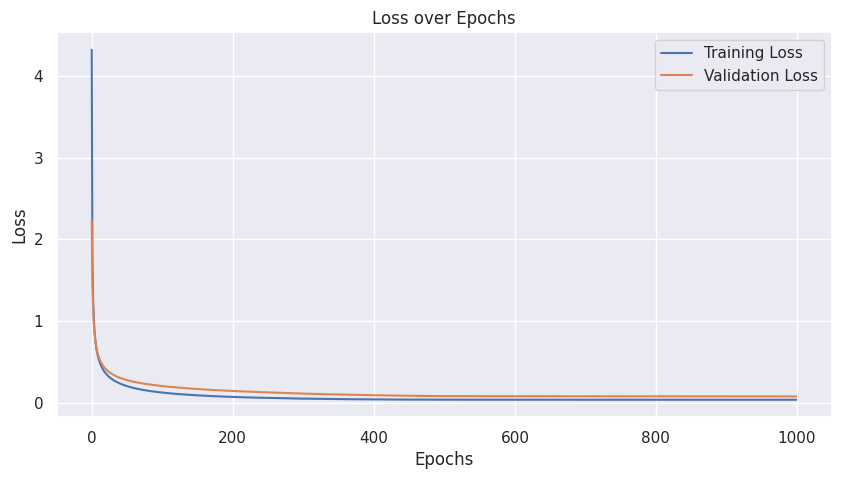

Время обучения MLP: 1832.3776 секунд


In [70]:
start_time = time.time()
f_mlp.fit(X_train_mn, y_train_mn, X_test_mn, y_test_mn, lr=0.015)
fit_time_f_mlp = time.time() - start_time
print(f"Время обучения MLP: {fit_time_f_mlp:.4f} секунд")

In [75]:
y_pred_f_mlp = f_mlp.predict(X_test_mn)

In [76]:
f_mlp_metr = f_mlp.compute_metrics(y_test_mn, y_pred_f_mlp)                        

In [77]:
print(f'\nAccuracy: {f_mlp_metr["Accuracy"]} \n Class-specific metrics:')
for label, metrics_f_mlp in f_mlp_metr["Class Metrics"].items():
    print(f"Class {label}\n  Precision: {metrics_f_mlp['precision']:.2f}\n  Recall: {metrics_f_mlp['recall']:.2f}\n \
 F1-Score: {metrics_f_mlp['f1_score']:.2f}")


Accuracy: 0.9752142857142857 
 Class-specific metrics:
Class 0
  Precision: 0.99
  Recall: 0.99
  F1-Score: 0.99
Class 1
  Precision: 0.98
  Recall: 0.99
  F1-Score: 0.99
Class 2
  Precision: 0.97
  Recall: 0.98
  F1-Score: 0.97
Class 3
  Precision: 0.98
  Recall: 0.96
  F1-Score: 0.97
Class 4
  Precision: 0.97
  Recall: 0.97
  F1-Score: 0.97
Class 5
  Precision: 0.98
  Recall: 0.98
  F1-Score: 0.98
Class 6
  Precision: 0.98
  Recall: 0.99
  F1-Score: 0.98
Class 7
  Precision: 0.97
  Recall: 0.98
  F1-Score: 0.98
Class 8
  Precision: 0.97
  Recall: 0.96
  F1-Score: 0.96
Class 9
  Precision: 0.96
  Recall: 0.96
  F1-Score: 0.96


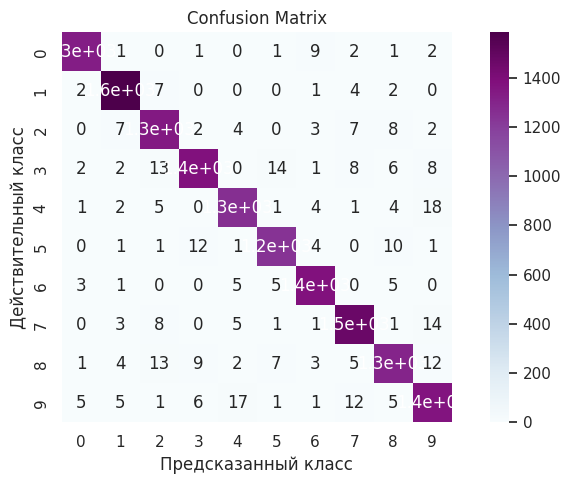

In [78]:
confusion_matrix_visualisation(f_mlp_metr["Confusion Matrix"])

In [396]:
np.unique(y_train_mn).shape[0]

10